# Benchmarking classification models on MNIST-1D

In [1]:
import sys
sys.path.append('./mnist1d/notebooks/')
sys.path.append('./mnist1d/mnist1d/')

from models import ConvBase, MLPBase, LinearBase, GRUBase
from train import get_model_args, train_model
from mnist1d.utils import set_seed

import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

import pickle


In [2]:
with open("/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl", "rb") as f:
    data = pickle.load(f)

## Run the benchmarks

In [3]:
# Note: if you run on a GPU, the walltimes will be _much_ lower

args = get_model_args()
args.total_steps = 6000
args.device = DEVICE

set_seed(args.seed)
model = ConvBase(output_size=args.output_size)
results_cnn = train_model(data, model, args)
print()

set_seed(args.seed)
model = GRUBase(input_size=1, output_size=args.output_size)
results_gru = train_model(data, model, args)
print()

set_seed(args.seed)
model = MLPBase(args.input_size, args.output_size)
results_mlp = train_model(data, model, args)
print()

set_seed(args.seed)
model = LinearBase(args.input_size, args.output_size)
results_lin = train_model(data, model, args)

Initialized ConvBase model with 5210 parameters
step 1000, dt 1.69s, train_loss 8.587e-02, test_loss 4.124e-01, train_acc 96.7, test_acc 89.2
step 2000, dt 1.58s, train_loss 1.540e-02, test_loss 4.419e-01, train_acc 97.8, test_acc 92.8
step 3000, dt 1.50s, train_loss 2.345e-02, test_loss 4.931e-01, train_acc 99.2, test_acc 91.9
step 4000, dt 1.40s, train_loss 3.243e-03, test_loss 3.617e-01, train_acc 100.0, test_acc 93.2
step 5000, dt 1.38s, train_loss 1.476e-04, test_loss 3.796e-01, train_acc 100.0, test_acc 93.8
step 6000, dt 1.36s, train_loss 7.728e-05, test_loss 3.994e-01, train_acc 100.0, test_acc 93.9

Initialized GRUBase model with 5134 parameters
step 1000, dt 11.52s, train_loss 1.585e-01, test_loss 4.120e-01, train_acc 93.5, test_acc 87.4
step 2000, dt 11.31s, train_loss 5.306e-02, test_loss 3.638e-01, train_acc 98.3, test_acc 90.2
step 3000, dt 11.65s, train_loss 3.734e-02, test_loss 4.497e-01, train_acc 97.2, test_acc 88.0
step 4000, dt 11.22s, train_loss 1.669e-02, test_los

In [4]:
# Shuffle the pixels

import numpy as np

np.random.seed(42)
shuffled_order = np.random.permutation(data['x'].shape[1])

data_shuff = data.copy()
data_shuff['x'] = data_shuff['x'][:, shuffled_order]
data_shuff['x_test'] = data_shuff['x_test'][:, shuffled_order]

In [5]:
set_seed(args.seed)
model = ConvBase(output_size=args.output_size)
results_cnn_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = GRUBase(input_size=1, output_size=args.output_size)
results_gru_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = MLPBase(args.input_size, args.output_size)
results_mlp_shuff = train_model(data_shuff, model, args)
print()

set_seed(args.seed)
model = LinearBase(args.input_size, args.output_size)
results_lin_shuff = train_model(data_shuff, model, args)

Initialized ConvBase model with 5210 parameters
step 1000, dt 1.49s, train_loss 6.388e-01, test_loss 1.572e+00, train_acc 75.7, test_acc 54.8
step 2000, dt 1.40s, train_loss 3.823e-01, test_loss 2.226e+00, train_acc 86.8, test_acc 55.7
step 3000, dt 1.42s, train_loss 2.166e-01, test_loss 2.984e+00, train_acc 93.8, test_acc 56.8
step 4000, dt 1.51s, train_loss 1.404e-01, test_loss 3.474e+00, train_acc 94.5, test_acc 55.9
step 5000, dt 1.38s, train_loss 1.043e-01, test_loss 4.285e+00, train_acc 95.6, test_acc 57.8
step 6000, dt 1.50s, train_loss 9.359e-02, test_loss 5.396e+00, train_acc 93.0, test_acc 56.0

Initialized GRUBase model with 5134 parameters
step 1000, dt 11.22s, train_loss 7.491e-01, test_loss 1.180e+00, train_acc 73.0, test_acc 55.5
step 2000, dt 11.39s, train_loss 5.001e-01, test_loss 1.584e+00, train_acc 76.7, test_acc 52.0
step 3000, dt 11.36s, train_loss 4.892e-01, test_loss 1.813e+00, train_acc 80.5, test_acc 51.5
step 4000, dt 11.26s, train_loss 4.025e-01, test_loss 2

## Construct the figure

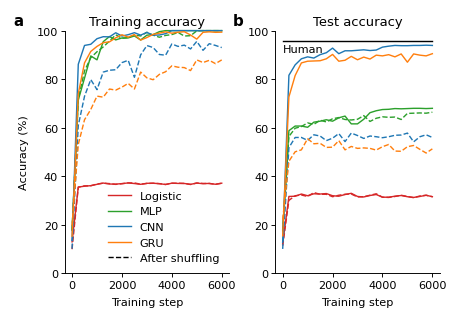

In [6]:
import pylab as plt

# Figure style (loading from the web to make running in a Colab easier)
plt.style.use('https://github.com/greydanus/mnist1d/raw/master/notebooks/mpl_style.txt')

fig, axs = plt.subplots(ncols=2, figsize=(3.25, 2.25))

steps = 6000
eval_every = 250
t = range(0, steps + 1, eval_every)

axs[0].plot(t, results_lin['train_acc'], '-', color='tab:red', label='Logistic')
axs[0].plot(t, results_lin_shuff['train_acc'], '--', color='tab:red')

axs[0].plot(t, results_mlp['train_acc'], '-', color='tab:green', label='MLP', clip_on=False)
axs[0].plot(t, results_mlp_shuff['train_acc'], '--', color='tab:green', clip_on=False)

axs[0].plot(t, results_cnn['train_acc'], '-', color='tab:blue', label='CNN', clip_on=False)
axs[0].plot(t, results_cnn_shuff['train_acc'], '--', color='tab:blue', clip_on=False)

axs[0].plot(t, results_gru['train_acc'], '-', color='tab:orange', label='GRU', clip_on=False)
axs[0].plot(t, results_gru_shuff['train_acc'], '--', color='tab:orange', clip_on=False)

axs[0].plot(t, [-1] * len(t), 'k--', label='After shuffling')

###

axs[1].plot(t, results_lin['test_acc'], '-', color='tab:red', label='logistic')
axs[1].plot(t, results_lin_shuff['test_acc'], '--', color='tab:red')

axs[1].plot(t, results_mlp['test_acc'], '-', color='tab:green', label='mlp')
axs[1].plot(t, results_mlp_shuff['test_acc'], '--', color='tab:green')

axs[1].plot(t, results_cnn['test_acc'], '-', color='tab:blue', label='cnn')
axs[1].plot(t, results_cnn_shuff['test_acc'], '--', color='tab:blue')

axs[1].plot(t, results_gru['test_acc'], '-', color='tab:orange', label='gru')
axs[1].plot(t, results_gru_shuff['test_acc'], '--', color='tab:orange')

axs[1].plot(t, [95.8] * len(t), 'k-')
axs[1].text(0, 91, 'Human')

axs[0].set_title('Training accuracy')
axs[1].set_title('Test accuracy')
axs[1].set_xlabel("Training step")
axs[0].set_xlabel("Training step")
axs[0].set_ylabel("Accuracy (%)")
axs[0].legend()
axs[0].set_ylim(0, 100)
axs[1].set_ylim(0, 100)

fig.text(0, .95, 'a', fontsize=8, weight='bold')
fig.text(.5, .95, 'b', fontsize=8, weight='bold')

plt.show()

fig.savefig('figures/benchmark.png', dpi=300)
fig.savefig('figures/benchmark.pdf')

In [7]:
# Model Accuracy (%) table

from IPython.display import display, HTML
from html import escape

def final_test_acc(results_name):
    """Get the final test accuracy from a results_* object."""
    results = globals().get(results_name)

    if not isinstance(results, dict):
        return "—"

    test_acc = results.get("test_acc")

    if test_acc is None or len(test_acc) == 0:
        return "—"

    return f"{float(test_acc[-1]):.0f}"

headers = [
    "Dataset",
    "Logistic regression",
    "MLP",
    "CNN",
    "GRU",
    "Human expert",
]

rows = [
    [
        "MNIST",
        "94 ± 0.5",
        "> 99",
        "> 99",
        "> 99",
        "> 99",
    ],
    [
        "MNIST-1D",
        final_test_acc("results_lin"),
        final_test_acc("results_mlp"),
        final_test_acc("results_cnn"),
        final_test_acc("results_gru"),
        "96 ± 1",
    ],
    [
        "MNIST-1D (shuffled)",
        final_test_acc("results_lin_shuff"),
        final_test_acc("results_mlp_shuff"),
        final_test_acc("results_cnn_shuff"),
        final_test_acc("results_gru_shuff"),
        "~30 ± 10",
    ],
]

header_html = "".join(f"<th>{escape(h)}</th>" for h in headers)

rows_html = ""
for row in rows:
    rows_html += "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"

html = f"""
<h3>Model Accuracy (%)</h3>
<table style="border-collapse: collapse; text-align: center;">
    <thead>
        <tr>{header_html}</tr>
    </thead>
    <tbody>
        {rows_html}
    </tbody>
</table>
<style>
    table th, table td {{
        border: 1px solid #999;
        padding: 6px 12px;
    }}
    table th:first-child,
    table td:first-child {{
        text-align: left;
    }}
</style>
"""

display(HTML(html))

Dataset,Logistic regression,MLP,CNN,GRU,Human expert
MNIST,94 ± 0.5,> 99,> 99,> 99,> 99
MNIST-1D,32,68,94,90,96 ± 1
MNIST-1D (shuffled),32,66,56,51,~30 ± 10


In [8]:
def run_marker_accuracy_experiments(
    default_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl",
    marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_x_length_50_with_marker.pkl",
    reversed_marker_url="/home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_x_length_50_with_marker_reversed.pkl",
    total_steps=6000,
    use_marker_as_input=True,
    run_shuffled=True,
):
    import sys
    import os
    import pickle
    import copy
    import numpy as np

    sys.path.append("./mnist1d/notebooks/")
    sys.path.append("./mnist1d/mnist1d/")

    import torch
    import torch.nn as nn

    from models import MLPBase, LinearBase
    from train import get_model_args, train_model
    from mnist1d.utils import set_seed

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # ------------------------------------------------------
    # Length-flexible models
    # ------------------------------------------------------

    class ConvSignalBase(nn.Module):
        """
        Standard one-channel CNN.

        Input format:
            x shape = (batch, seq_len)

        For marked data:
            seq_len = 50

        For vanilla data:
            seq_len = 40
        """

        def __init__(self, seq_len, output_size=10):
            super().__init__()
            self.seq_len = seq_len

            self.features = nn.Sequential(
                nn.Conv1d(1, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.Conv1d(25, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
                nn.Conv1d(25, 25, kernel_size=5, stride=2, padding=2),
                nn.ReLU(),
            )

            with torch.no_grad():
                dummy = torch.zeros(1, 1, seq_len)
                flat_dim = self.features(dummy).reshape(1, -1).shape[1]

            self.classifier = nn.Linear(flat_dim, output_size)

        def forward(self, x):
            batch_size = x.shape[0]
            x = x.reshape(batch_size, 1, self.seq_len)
            x = self.features(x)
            x = x.reshape(batch_size, -1)
            return self.classifier(x)

    class GRUSignalBase(nn.Module):
        """
        Standard one-channel GRU.

        Input format:
            x shape = (batch, seq_len)

        Internally:
            x shape = (batch, seq_len, 1)
        """

        def __init__(self, seq_len, output_size=10, hidden_size=64):
            super().__init__()
            self.seq_len = seq_len

            self.gru = nn.GRU(
                input_size=1,
                hidden_size=hidden_size,
                batch_first=True,
            )

            self.classifier = nn.Linear(hidden_size, output_size)

        def forward(self, x):
            batch_size = x.shape[0]
            x = x.reshape(batch_size, self.seq_len, 1)
            out, hidden = self.gru(x)
            return self.classifier(out[:, -1, :])

    # ------------------------------------------------------
    # Helpers
    # ------------------------------------------------------

    def load_pkl(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Could not find: {path}")

        with open(path, "rb") as f:
            return pickle.load(f)

    def get_original_seq_len(data):
        """
        Finds the original MNIST-1D length.

        For the new marked files, this should usually be 40.
        """
        if "marker_info" in data:
            info = data["marker_info"]

            if "old_sequence_length" in info:
                return int(info["old_sequence_length"])

            if "original_sequence_length" in info:
                return int(info["original_sequence_length"])

        if "x_original" in data:
            return data["x_original"].shape[1]

        return data["x"].shape[1]

    def strip_marker_from_x_if_present(data):
        """
        Used only when use_marker_as_input=False.

        If the dataset has x_original, use it.
        Otherwise crop x back to the original sequence length.
        """
        data = copy.deepcopy(data)

        if "x_original" in data:
            data["x"] = data["x_original"].copy()
        else:
            original_len = get_original_seq_len(data)
            data["x"] = data["x"][:, :original_len]

        if "x_test_original" in data:
            data["x_test"] = data["x_test_original"].copy()
        else:
            original_len = get_original_seq_len(data)
            data["x_test"] = data["x_test"][:, :original_len]

        if "t_original" in data:
            data["t"] = data["t_original"].copy()
        elif "t" in data:
            data["t"] = data["t"][: data["x"].shape[1]]

        return data

    def pad_x_test_to_length(test_data, target_len, blank_value=0.0):
        """
        Pads x_test to match the training sequence length.

        This is needed for:
            marked train length 50 -> default test length 40

        The padding uses the same dtype as x_test.
        """
        test_data = copy.deepcopy(test_data)

        x_test = test_data["x_test"]
        old_len = x_test.shape[1]

        if old_len == target_len:
            return test_data

        if old_len > target_len:
            raise ValueError(
                f"x_test length {old_len} is larger than target length {target_len}."
            )

        x_test_new = np.full(
            (x_test.shape[0], target_len),
            np.array(blank_value, dtype=x_test.dtype),
            dtype=x_test.dtype,
        )

        x_test_new[:, :old_len] = x_test
        test_data["x_test"] = x_test_new

        return test_data

    def make_model_input_data(train_data, test_data, use_marker):
        train_data = copy.deepcopy(train_data)
        test_data = copy.deepcopy(test_data)

        if not use_marker:
            train_data = strip_marker_from_x_if_present(train_data)
            test_data = strip_marker_from_x_if_present(test_data)

        seq_len = train_data["x"].shape[1]

        # Important:
        # The marker is already inside x.
        # Do NOT concatenate x with marker_mask anymore.
        x_train = train_data["x"]

        # If train is length 50 and test is vanilla length 40,
        # pad the test signal to length 50.
        test_data = pad_x_test_to_length(test_data, target_len=seq_len)

        x_test = test_data["x_test"]

        data = {
            "x": x_train,
            "y": train_data["y"],
            "x_test": x_test,
            "y_test": test_data["y_test"],
        }

        if "t" in train_data:
            data["t"] = train_data["t"]

        return data, seq_len

    def make_shuffled_data(data, seq_len, use_marker):
        """
        Shuffle the full signal as one normal 1D input.

        For marked data this means shuffling all 50 positions together.
        There is no separate marker_mask channel anymore.
        """
        data_shuff = copy.deepcopy(data)

        np.random.seed(42)

        order = np.random.permutation(data["x"].shape[1])

        data_shuff["x"] = data["x"][:, order]
        data_shuff["x_test"] = data["x_test"][:, order]

        return data_shuff

    def final_acc(results):
        test_acc = results.get("test_acc")
        if test_acc is None or len(test_acc) == 0:
            return None
        return float(test_acc[-1])

    def format_acc(value):
        if value is None:
            return "—"
        return f"{value:.1f}"

    # ------------------------------------------------------
    # Training
    # ------------------------------------------------------

    def train_all_models(data, experiment_name, seq_len):
        print()
        print("=" * 80)
        print(experiment_name)
        print("=" * 80)
        print("x:", data["x"].shape)
        print("y:", data["y"].shape)
        print("x_test:", data["x_test"].shape)
        print("y_test:", data["y_test"].shape)
        print("x dtype:", data["x"].dtype)
        print("x_test dtype:", data["x_test"].dtype)

        args = get_model_args()
        args.total_steps = total_steps
        args.device = DEVICE
        args.input_size = data["x"].shape[1]

        results = {}

        set_seed(args.seed)
        model = ConvSignalBase(seq_len=seq_len, output_size=args.output_size)
        results["CNN"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        model = GRUSignalBase(seq_len=seq_len, output_size=args.output_size)
        results["GRU"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        model = MLPBase(args.input_size, args.output_size)
        results["MLP"] = train_model(data, model, args)
        print()

        set_seed(args.seed)
        model = LinearBase(args.input_size, args.output_size)
        results["Logistic"] = train_model(data, model, args)
        print()

        return results

    def train_case(case_name, train_data, test_data, use_marker):
        data, seq_len = make_model_input_data(
            train_data=train_data,
            test_data=test_data,
            use_marker=use_marker,
        )

        results = train_all_models(
            data=data,
            experiment_name=case_name,
            seq_len=seq_len,
        )

        if run_shuffled:
            data_shuff = make_shuffled_data(
                data=data,
                seq_len=seq_len,
                use_marker=use_marker,
            )

            results_shuff = train_all_models(
                data=data_shuff,
                experiment_name=case_name + " shuffled",
                seq_len=seq_len,
            )
        else:
            results_shuff = None

        return {
            "normal": results,
            "shuffled": results_shuff,
        }

    # ------------------------------------------------------
    # Load data
    # ------------------------------------------------------

    default_data = load_pkl(default_url)
    marker_data = load_pkl(marker_url)
    reversed_marker_data = load_pkl(reversed_marker_url)

    print("Loaded datasets:")
    print("Default:", default_url)
    print("Marker:", marker_url)
    print("Reversed marker:", reversed_marker_url)

    print()
    print("Default x shape:", default_data["x"].shape)
    print("Marker x shape:", marker_data["x"].shape)
    print("Reversed marker x shape:", reversed_marker_data["x"].shape)

    if use_marker_as_input:
        print()
        print("Marker is used as model input.")
        print("Input format: x already contains the marker as part of the signal.")
        print("No marker_mask concatenation is used.")
        print("CNN/GRU use standard one-channel models with flexible sequence length.")
    else:
        print()
        print("Marker is ignored.")
        print("If x_original exists, models see x_original.")
        print("Otherwise x is cropped back to the original MNIST-1D length.")

    # ------------------------------------------------------
    # Experiments
    # ------------------------------------------------------

    vanilla_results = train_case(
        case_name="Vanilla train → vanilla test",
        train_data=default_data,
        test_data=default_data,
        use_marker=False,
    )

    marker_default_results = train_case(
        case_name="Marked train → default test",
        train_data=marker_data,
        test_data=default_data,
        use_marker=use_marker_as_input,
    )

    marker_marker_results = train_case(
        case_name="Marked train → marked test",
        train_data=marker_data,
        test_data=marker_data,
        use_marker=use_marker_as_input,
    )

    marker_reversed_results = train_case(
        case_name="Marked train → reversed-marker test",
        train_data=marker_data,
        test_data=reversed_marker_data,
        use_marker=use_marker_as_input,
    )

    # ------------------------------------------------------
    # Single combined table
    # ------------------------------------------------------

    def row_from_results(name, bundle):
        normal = bundle["normal"]
        shuffled = bundle["shuffled"]

        row = {
            "Case": name,
            "Logistic": format_acc(final_acc(normal["Logistic"])),
            "MLP": format_acc(final_acc(normal["MLP"])),
            "CNN": format_acc(final_acc(normal["CNN"])),
            "GRU": format_acc(final_acc(normal["GRU"])),
        }

        if run_shuffled:
            row.update(
                {
                    "Logistic shuffled": format_acc(final_acc(shuffled["Logistic"])),
                    "MLP shuffled": format_acc(final_acc(shuffled["MLP"])),
                    "CNN shuffled": format_acc(final_acc(shuffled["CNN"])),
                    "GRU shuffled": format_acc(final_acc(shuffled["GRU"])),
                }
            )

        return row

    all_rows = [
        row_from_results("Vanilla train → default test", vanilla_results),
        row_from_results("Marked train → default test", marker_default_results),
        row_from_results("Marked train → marked test", marker_marker_results),
        row_from_results("Marked train → reversed-marked test", marker_reversed_results),
    ]

    columns = ["Case", "Logistic", "MLP", "CNN", "GRU"]

    if run_shuffled:
        columns += [
            "Logistic shuffled",
            "MLP shuffled",
            "CNN shuffled",
            "GRU shuffled",
        ]

    # ------------------------------------------------------
    # Display one table only
    # ------------------------------------------------------

    try:
        from IPython.display import display, HTML
        from html import escape

        def html_table(title, rows, columns):
            header_html = "".join(f"<th>{escape(col)}</th>" for col in columns)

            rows_html = ""
            for row in rows:
                rows_html += "<tr>"
                for col in columns:
                    rows_html += f"<td>{escape(str(row[col]))}</td>"
                rows_html += "</tr>"

            return f"""
            <h3>{escape(title)}</h3>

            <table style="border-collapse: collapse; text-align: center; font-size: 13px;">
                <thead>
                    <tr>{header_html}</tr>
                </thead>
                <tbody>
                    {rows_html}
                </tbody>
            </table>

            <style>
                table th, table td {{
                    border: 1px solid #999;
                    padding: 6px 10px;
                }}
                table th:first-child,
                table td:first-child {{
                    text-align: left;
                    white-space: nowrap;
                }}
            </style>
            """

        display(
            HTML(
                html_table(
                    "Final test accuracy (%)",
                    all_rows,
                    columns,
                )
            )
        )

    except Exception:
        print()
        print("Final test accuracy (%)")
        for row in all_rows:
            print(row)

    return {
        "vanilla": vanilla_results,
        "marked_train_default_test": marker_default_results,
        "marked_train_marked_test": marker_marker_results,
        "marked_train_reversed_test": marker_reversed_results,
        "rows": all_rows,
    }

In [9]:
results = run_marker_accuracy_experiments(
    total_steps=6000,
    use_marker_as_input=True,
    run_shuffled=True,
)

Loaded datasets:
Default: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data.pkl
Marker: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_x_length_50_with_marker.pkl
Reversed marker: /home/christian/FRMDL_toy_dataset/mnist1d/mnist1d_data_x_length_50_with_marker_reversed.pkl

Default x shape: (4000, 40)
Marker x shape: (4000, 50)
Reversed marker x shape: (4000, 50)

Marker is used as model input.
Input format: x already contains the marker as part of the signal.
No marker_mask concatenation is used.
CNN/GRU use standard one-channel models with flexible sequence length.

Vanilla train → vanilla test
x: (4000, 40)
y: (4000,)
x_test: (1000, 40)
y_test: (1000,)
x dtype: float64
x_test dtype: float64
step 1000, dt 1.49s, train_loss 3.247e-02, test_loss 4.032e-01, train_acc 97.5, test_acc 89.7
step 2000, dt 1.47s, train_loss 1.196e-03, test_loss 3.479e-01, train_acc 100.0, test_acc 93.5
step 3000, dt 1.44s, train_loss 8.379e-05, test_loss 3.881e-01, train_acc 100.0, test_acc 94.1
st

Case,Logistic,MLP,CNN,GRU,Logistic shuffled,MLP shuffled,CNN shuffled,GRU shuffled
Vanilla train → default test,31.5,65.8,94.4,97.6,31.5,66.2,60.5,52.8
Marked train → default test,27.5,40.5,54.5,81.1,27.8,41.8,38.5,36.5
Marked train → marked test,48.1,76.6,98.1,98.6,48.7,77.6,75.7,70.9
Marked train → reversed-marked test,0.0,5.9,2.8,8.1,0.0,4.3,10.7,4.9
